## Ames Housing Price Prediction Challenge

### 📋 Assignment Overview

**Objective**: Build a complete machine learning pipeline to predict house prices using the famous **Ames Housing Dataset** - a real-world dataset containing detailed information about residential properties in Ames, Iowa.

**Problem Type**: Regression (Predicting continuous house sale prices)
**Dataset**: Ames Housing Dataset (2,930 houses, 80+ features, 2006-2010)
**Industry Context**: Real estate valuation and investment decision-making

---

## 🎯 Why This Dataset?

The **Ames Housing Dataset** is considered the modern replacement for the Boston Housing dataset and offers several advantages:

- ✅ **Real-world complexity**: 80+ features covering every aspect of residential properties
- ✅ **Rich categorical data**: Multiple categorical variables requiring different encoding strategies
- ✅ **Realistic missing data**: Structural and random missing values typical in real estate
- ✅ **Industry relevance**: Used by data scientists at Zillow, Redfin, and other real estate companies
- ✅ **Educational gold standard**: Created specifically for teaching advanced regression techniques

---

## 📊 Dataset Description

### Ames Housing Dataset Features:

**Property Basics:**
- `SalePrice` - **Target Variable** (Sale price in USD)
- `MSSubClass` - Type of dwelling involved in the sale
- `MSZoning` - General zoning classification
- `LotFrontage` - Linear feet of street connected to property
- `LotArea` - Lot size in square feet
- `Street` - Type of road access to property

**House Characteristics:**
- `OverallQual` - Overall material and finish quality (1-10)
- `OverallCond` - Overall condition rating (1-10)
- `YearBuilt` - Original construction date
- `YearRemodAdd` - Remodel date (same as construction if no remodeling)
- `RoofStyle` - Type of roof
- `Exterior1st/2nd` - Exterior covering on house

**Size Features:**
- `GrLivArea` - Above grade living area square feet
- `1stFlrSF` - First Floor square feet
- `2ndFlrSF` - Second floor square feet
- `TotalBsmtSF` - Total square feet of basement area
- `GarageArea` - Size of garage in square feet

**Quality Features:**
- `ExterQual` - Exterior material quality
- `BsmtQual` - Height of the basement
- `HeatingQC` - Heating quality and condition
- `KitchenQual` - Kitchen quality
- `FireplaceQu` - Fireplace quality

**Location & Amenities:**
- `Neighborhood` - Physical locations within Ames city limits
- `Condition1/2` - Proximity to various conditions
- `CentralAir` - Central air conditioning
- `Fireplaces` - Number of fireplaces
- `PoolArea` - Pool area in square feet
- `GarageCars` - Size of garage in car capacity

**...and 60+ more features!**

### Dataset Characteristics:
- **Observations**: 2,930 houses
- **Features**: 80+ variables (categorical, numerical, ordinal)
- **Target**: SalePrice (continuous)
- **Time Period**: 2006-2010
- **Location**: Ames, Iowa
- **Missing Values**: ~20% of cells (mostly structural)
- **Data Quality Issues**: Mixed formats, outliers, encoding challenges

---


## 📥 Dataset Access

### Option 1: Kaggle Competition (Recommended)


In [ ]:
# Visit: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques
# Download: train.csv (for this assignment)


### Option 2: Kaggle API


In [ ]:
# !pip install kaggle
# !kaggle competitions download -c house-prices-advanced-regression-techniques

### Option 3: Direct Download


In [ ]:
# Alternative sources
# OpenIntro: https://www.openintro.org/data/index.php?data=ames
# GitHub: Various repositories with cleaned versions

In [ ]:
!pip install -U imbalanced-learn -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    MinMaxScaler,
    PolynomialFeatures,
    RobustScaler
)
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/machine_learning my copy/regression/ames.csv'
df = pd.read_csv(path)
print(df.head())
print(df['Pool.QC'].value_counts())
info=df.info()
print(info)

   Order        PID  area   price  MS.SubClass MS.Zoning  Lot.Frontage  \
0      1  526301100  1656  215000           20        RL         141.0   
1      2  526350040   896  105000           20        RH          80.0   
2      3  526351010  1329  172000           20        RL          81.0   
3      4  526353030  2110  244000           20        RL          93.0   
4      5  527105010  1629  189900           60        RL          74.0   

   Lot.Area Street Alley  ... Screen.Porch Pool.Area Pool.QC  Fence  \
0     31770   Pave   NaN  ...            0         0     NaN    NaN   
1     11622   Pave   NaN  ...          120         0     NaN  MnPrv   
2     14267   Pave   NaN  ...            0         0     NaN    NaN   
3     11160   Pave   NaN  ...            0         0     NaN    NaN   
4     13830   Pave   NaN  ...            0         0     NaN  MnPrv   

  Misc.Feature Misc.Val Mo.Sold Yr.Sold Sale.Type Sale.Condition  
0          NaN        0       5    2010       WD          Nor

In [ ]:
# ------Data_Quality_Assessment-------

# 1. Basic Shape and Structure
print(f"Dataset Shape: {df.shape}")
print("-" * 30)

# 2. Check for Duplicates
duplicates = df.duplicated().sum()
print(f"Number of Duplicate Rows: {duplicates}")

# 3. Missing Values Summary (Sorted by % Missing)
null_counts = df.isnull().sum()
null_percent = (null_counts / len(df)) * 100
missing_data = pd.concat([null_counts, null_percent], axis=1, keys=['Total', 'Percent'])

# Only show columns that actually have missing values
missing_data = missing_data[missing_data['Total'] > 0].sort_values(by='Percent', ascending=False)

print("\nColumns with Missing Values:")
print(missing_data) # Looking at the top 20 troublemakers

# 4. Statistical Overview of the Target (SalePrice)
print("\nTarget Variable (SalePrice) Summary:")
print(df['price'].describe())

# 5. Now we need to identify the data_types in each and every single columns
# weather it is a string or value
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"Total Numeric Columns: {(numeric_cols)}")
print(f"Total Categorical Columns: {(categorical_cols)}")

print(f"Total Numeric Columns: {len((numeric_cols))}")
print(f"Total Categorical Columns: {len((categorical_cols))}")

# 6. identifying where are the columns with nans in numeric columns

null_counts_numeric= df[numeric_cols].isnull().sum()

# 7. identifying where are the columns with nans in categorical columns

null_counts_categorical= df[categorical_cols].isnull().sum()
print(f'Columns with null counts in numeric columns:\n{null_counts_numeric[null_counts_numeric>0]}')
print(f'Columns with null counts in categorical columns:\n{null_counts_categorical[null_counts_categorical>0]}')

Dataset Shape: (2930, 82)
------------------------------
Number of Duplicate Rows: 0

Columns with Missing Values:
                Total    Percent
Pool.QC          2917  99.556314
Misc.Feature     2824  96.382253
Alley            2732  93.242321
Fence            2358  80.477816
Mas.Vnr.Type     1775  60.580205
Fireplace.Qu     1422  48.532423
Lot.Frontage      490  16.723549
Garage.Qual       159   5.426621
Garage.Cond       159   5.426621
Garage.Yr.Blt     159   5.426621
Garage.Finish     159   5.426621
Garage.Type       157   5.358362
Bsmt.Exposure      83   2.832765
BsmtFin.Type.2     81   2.764505
Bsmt.Cond          80   2.730375
Bsmt.Qual          80   2.730375
BsmtFin.Type.1     80   2.730375
Mas.Vnr.Area       23   0.784983
Bsmt.Full.Bath      2   0.068259
Bsmt.Half.Bath      2   0.068259
BsmtFin.SF.1        1   0.034130
BsmtFin.SF.2        1   0.034130
Electrical          1   0.034130
Total.Bsmt.SF       1   0.034130
Bsmt.Unf.SF         1   0.034130
Garage.Area         1   0.0

In [ ]:
'''
This is a function that determine wether the column is a numeric column
or a categorical column.
'''
def check_column_type(df, column_name):
    # Check if the column type is a number (int or float)
    if pd.api.types.is_numeric_dtype(df[column_name]):
        return "Numerical"
    else:
        return "Categorical"

# --- How to use it ---
# Just pass your dataframe and the name of the column you are curious about
result = check_column_type(df, 'price')
print(f"The column is: {result}")

result2 = check_column_type(df, 'Neighborhood')
print(f"The column is: {result2}")

The column is: Numerical
The column is: Categorical


In [ ]:
# --------FILLING THE NANS--------

# Fill the Garage Year with 0 to indicate "No Garage"
df['Garage.Yr.Blt'] = df['Garage.Yr.Blt'].fillna(0)

# Now you can safely fill the rest of the numeric columns with the median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# And fill all categorical columns with "None"
df[categorical_cols] = df[categorical_cols].fillna("None")
# final check
final_check_for_nans=df.isnull().sum()
print(f'After filling the nans the total count of nans inside the data_fram is:\n{len(final_check_for_nans[final_check_for_nans>0])}')

After filling the nans the total count of nans inside the data_fram is:
0


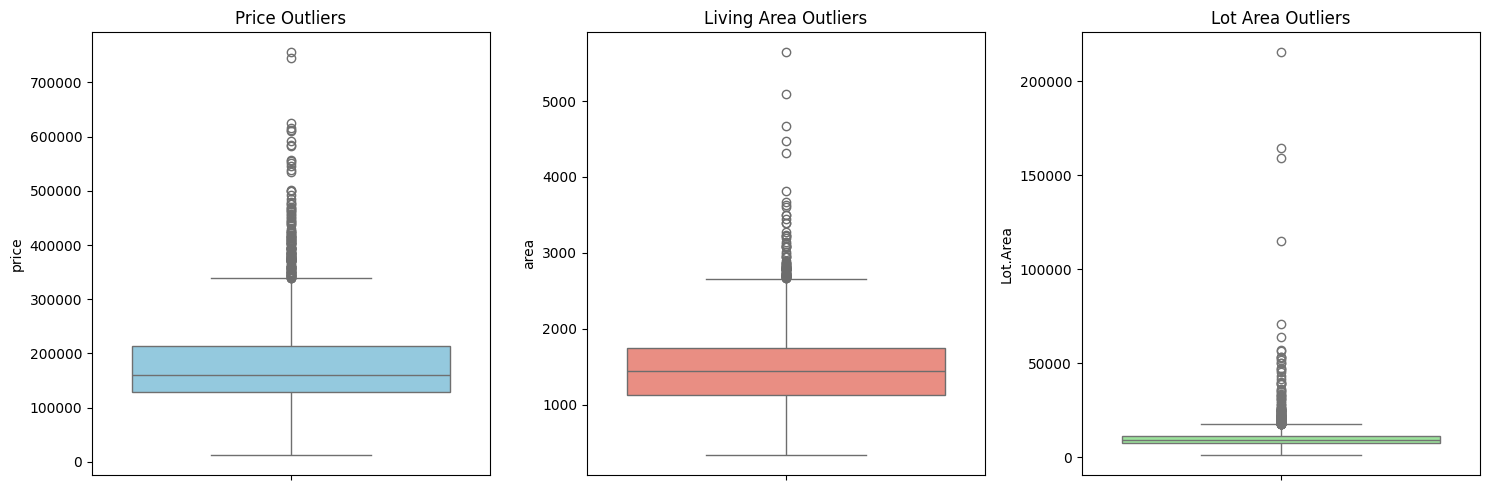

The Box starts at: $129,500
The Box ends at: $213,500
--- ANY HOUSE ABOVE $339,500 IS A CIRCLE (OUTLIER) ---


In [ ]:
# ------DATA VISUALIZATION & IDENTIFYING OUTLIERS------

# Create a figure with 3 subplots to see the 'Big Three'
plt.figure(figsize=(15, 5))

# 1. Price Outliers (The target we want to predict)
plt.subplot(1, 3, 1)
sns.boxplot(y=df['price'], color='skyblue')
plt.title('Price Outliers')

# 2. Area Outliers (This is your Gr.LivArea)
plt.subplot(1, 3, 2)
sns.boxplot(y=df['area'], color='salmon')
plt.title('Living Area Outliers')

# 3. Lot Area Outliers (The size of the land)
plt.subplot(1, 3, 3)
sns.boxplot(y=df['Lot.Area'], color='lightgreen')
plt.title('Lot Area Outliers')

plt.tight_layout()
plt.show()

# 1. Calculate the 25th and 75th percentile
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

# 2. Calculate the IQR (The height of the box)
IQR = Q3 - Q1

# 3. Calculate the "Top Whisker" (The threshold)
upper_limit = Q3 + (1.5 * IQR)

print(f"The Box starts at: ${Q1:,.0f}")
print(f"The Box ends at: ${Q3:,.0f}")
print(f"--- ANY HOUSE ABOVE ${upper_limit:,.0f} IS A CIRCLE (OUTLIER) ---")

In [ ]:
# --- Identifying the Outliers ---

# 1. Filter the dataframe for houses above the upper limit
outliers_df = df[df['price'] > upper_limit]
# 2. Sort them by price to see the "most extreme" ones first
outliers_df = outliers_df.sort_values(by='price', ascending=False)

# 3. Print the results
print(f"Total number of price outliers detected: {len(outliers_df)}")
print("-" * 30)
print("Top 10 most expensive outlier houses:")
# Showing specific columns to keep the output clean
print(outliers_df[['price', 'area', 'Neighborhood', 'Overall.Qual']].head(10))

# OPTIONAL: Save them to a CSV if you want to inspect them in Excel
# outliers_df.to_csv('price_outliers.csv', index=False)

Total number of price outliers detected: 137
------------------------------
Top 10 most expensive outlier houses:
       price  area Neighborhood  Overall.Qual
1767  755000  4316      NoRidge            10
1760  745000  4476      NoRidge            10
2445  625000  3627      NoRidge            10
1063  615000  2470      NridgHt            10
44    611657  2364      NridgHt             9
432   610000  2674      NridgHt            10
1637  591587  2338      StoneBr             9
2450  584500  3500      NoRidge             9
433   582933  2822      NridgHt             9
2332  556581  2868      StoneBr             9


In [ ]:
# ------CHECKING THE CORRELATION BETWEEN NUMERIC FEATURES AND PRICE (THE TARGET)
# 1. Calculate the correlation matrix
# We only do this for numeric columns
corr_matrix = df[numeric_cols].corr()

# 2. Pull the correlation of everything vs 'price'
# and sort it so the strongest are at the top
price_correlations = corr_matrix['price'].sort_values(ascending=False)

print("--- Top 10 Features Positively Correlated with Price ---")
print(price_correlations.head(11)) # 11 to include 'price' itself

print("\n--- Top 5 Features Negatively Correlated with Price ---")
print(price_correlations.tail(5))

--- Top 10 Features Positively Correlated with Price ---
price             1.000000
Overall.Qual      0.799262
area              0.706780
Garage.Cars       0.647812
Garage.Area       0.640381
Total.Bsmt.SF     0.632164
X1st.Flr.SF       0.621676
Year.Built        0.558426
Full.Bath         0.545604
Year.Remod.Add    0.532974
Mas.Vnr.Area      0.502196
Name: price, dtype: float64

--- Top 5 Features Negatively Correlated with Price ---
MS.SubClass      -0.085092
Overall.Cond     -0.101697
Kitchen.AbvGr    -0.119814
Enclosed.Porch   -0.128787
PID              -0.246521
Name: price, dtype: float64


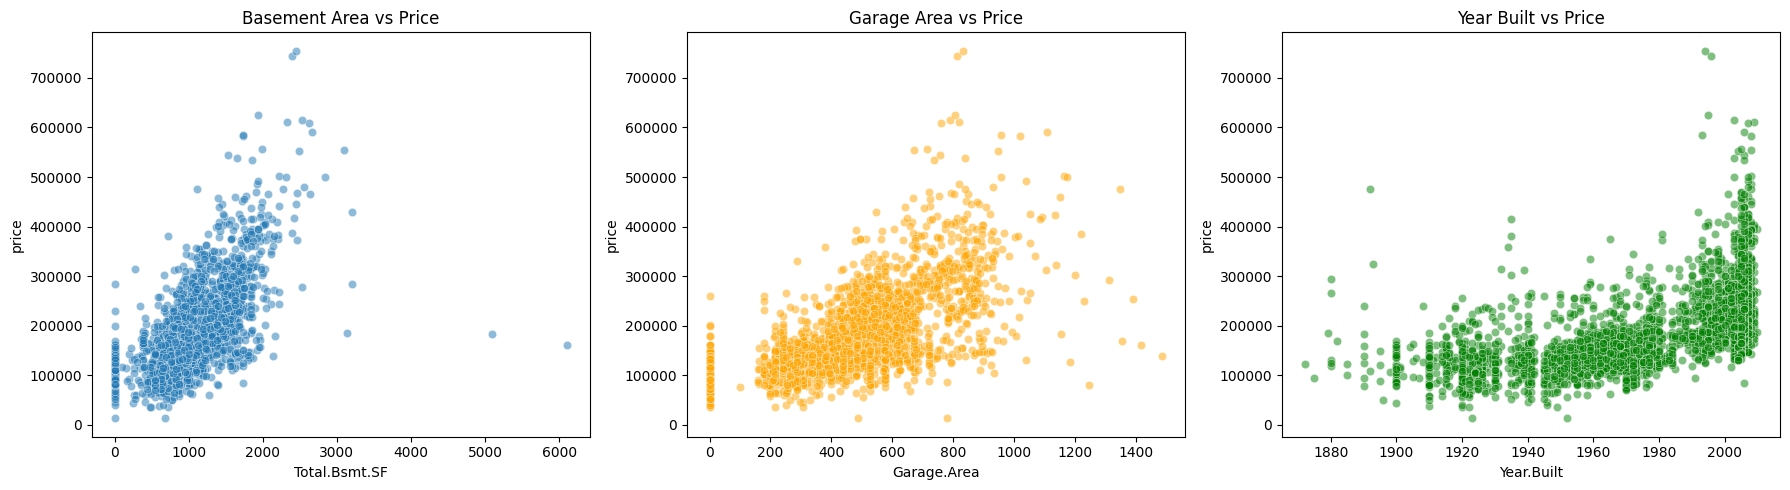

In [ ]:
# Create a 1x3 plot for the heaviest hitters
plt.figure(figsize=(18, 5))

# 1. Basement Size vs Price
plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x='Total.Bsmt.SF', y='price', alpha=0.5)
plt.title('Basement Area vs Price')

# 2. Garage Area vs Price
plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='Garage.Area', y='price', alpha=0.5, color='orange')
plt.title('Garage Area vs Price')

# 3. Year Built vs Price
plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='Year.Built', y='price', alpha=0.5, color='green')
plt.title('Year Built vs Price')

plt.tight_layout()
plt.show()

In [ ]:
# --- 1. PRE-SPLIT: GLOBAL CLEANING & FORMATTING ---
# Drop physical leverage outliers (errors)
df = df[df['Total.Bsmt.SF'] < 4000].copy()

# A. Ordinal Encoding (Ranking Quality)
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
ord_cols = [
    'Exter.Qual', 'Exter.Cond', 'Bsmt.Qual', 'Bsmt.Cond',
    'Heating.QC', 'Kitchen.Qual', 'Fireplace.Qu',
    'Garage.Qual', 'Garage.Cond', 'Pool.QC'
]

for col in ord_cols:
    if col in df.columns:
        df[col] = df[col].map(qual_map).fillna(0)

# B. Nominal Encoding (One-Hot for neighborhoods, etc.)
# We handle this before splitting to ensure both sets have identical column shapes
remaining_cats = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=remaining_cats, drop_first=True)

# Final formatting: ensure all values are float for the model
df = df.astype(float).fillna(0)


# --- 2. THE SPLIT (Strictly Numerical) ---
X = df.drop(['price'], axis=1)
y = df['price']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Second split: Split the 80% into Train (75% of 80% = 60%) and Val (25% of 80% = 20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

# --- 2. POST-SPLIT: TARGET TRANSFORMATION ---
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

# --- 3. POST-SPLIT: FEATURE HANDLING (The Firewall) ---

# A. Outlier Clipping (Rule learned from X_train ONLY)
upper_limit_garage = X_train['Garage.Area'].quantile(0.99)

X_train['Garage.Area'] = X_train['Garage.Area'].clip(upper=upper_limit_garage)
X_val['Garage.Area'] = X_val['Garage.Area'].clip(upper=upper_limit_garage)
X_test['Garage.Area'] = X_test['Garage.Area'].clip(upper=upper_limit_garage)

# B. Scaling (Fit on X_train ONLY)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Use Train's rules to scale Val and Test
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# --- 4. OUTPUT VERIFICATION ---
print("✅ Three-Way Split Complete")
print(f"X_train (60%): {X_train_scaled.shape}")
print(f"X_val   (20%): {X_val_scaled.shape}")
print(f"X_test  (20%): {X_test_scaled.shape}")

✅ Three-Way Split Complete
X_train (60%): (1756, 242)
X_val   (20%): (586, 242)
X_test  (20%): (586, 242)
✅ Three-Way Split Complete
X_train (60%): (1756, 242)
X_val   (20%): (586, 242)
X_test  (20%): (586, 242)


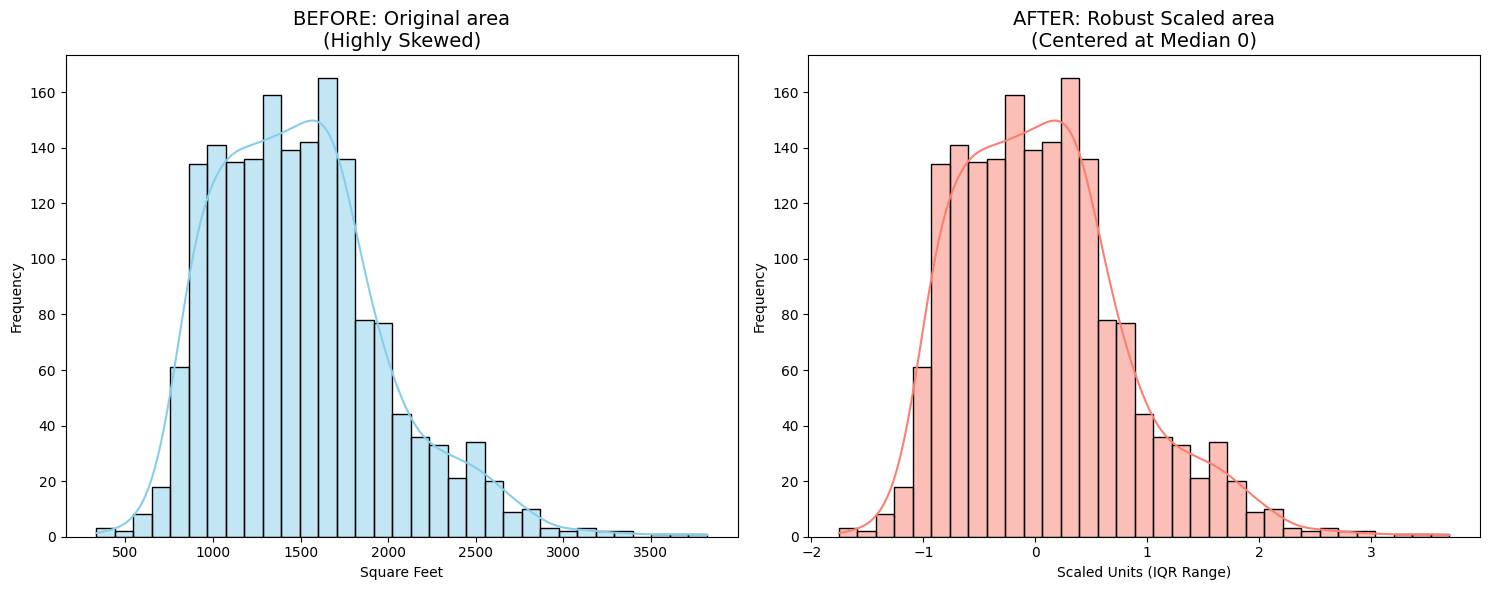

--- Statistics for 'area' ---
Original - Mean: 1497.66 | Max: 3820.00
Scaled   - Median: 0.00 | Max: 3.70


In [ ]:
# 1. Choose a feature to visualize (e.g., 'area')
# We need the index because X_train_scaled is a numpy array
feature_to_plot = 'area'
feature_idx = X.columns.get_loc(feature_to_plot)

# 2. Setup the side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- PLOT 1: BEFORE SCALING (Original Training Data) ---
sns.histplot(X_train[feature_to_plot], kde=True, color='skyblue', ax=ax1)
ax1.set_title(f'BEFORE: Original {feature_to_plot}\n(Highly Skewed)', fontsize=14)
ax1.set_xlabel('Square Feet')
ax1.set_ylabel('Frequency')

# --- PLOT 2: AFTER SCALING (Robust Scaled Training Data) ---
# We slice the numpy array using the index we found
sns.histplot(X_train_scaled[:, feature_idx], kde=True, color='salmon', ax=ax2)
ax2.set_title(f'AFTER: Robust Scaled {feature_to_plot}\n(Centered at Median 0)', fontsize=14)
ax2.set_xlabel('Scaled Units (IQR Range)')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# 3. Print Statistical Proof
print(f"--- Statistics for '{feature_to_plot}' ---")
print(f"Original - Mean: {X_train[feature_to_plot].mean():.2f} | Max: {X_train[feature_to_plot].max():.2f}")
print(f"Scaled   - Median: {np.median(X_train_scaled[:, feature_idx]):.2f} | Max: {X_train_scaled[:, feature_idx].max():.2f}")

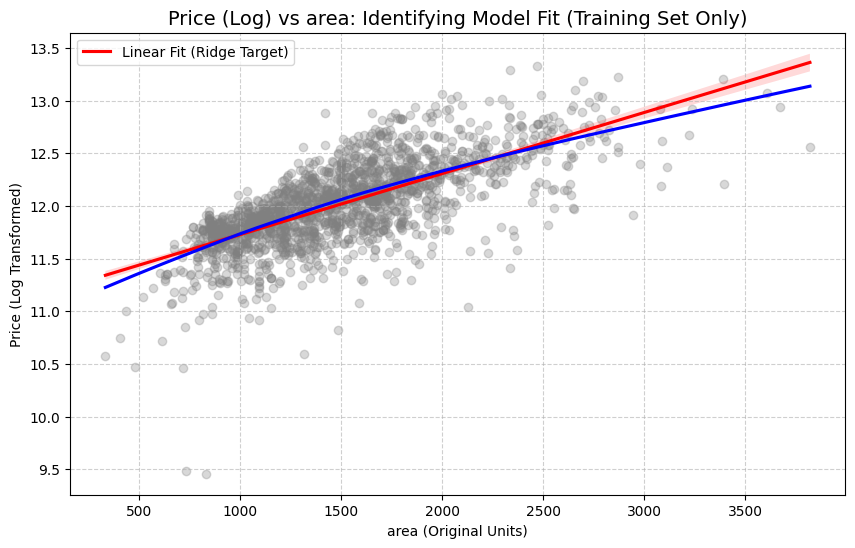

💡 HOW TO PICK YOUR MODEL:
- If the RED and BLUE lines are close: Use Ridge/Linear Regression.
- If the BLUE line curves significantly away: Consider Polynomial Features or a Tree-based model.


In [ ]:
# --- 1. PICK THE TRAINING DATA ---
# We use the unscaled training features so the X-axis (Square Feet) makes sense to us
feature_to_check = 'area'

plt.figure(figsize=(10, 6))

# --- 2. THE SCATTER & LINEAR TREND ---
# Notice we use X_train and y_train_log here
sns.regplot(x=X_train[feature_to_check], y=y_train_log,
            scatter_kws={'alpha':0.3, 'color':'gray'},
            line_kws={'color':'red', 'label':'Linear Fit (Ridge Target)'},
            lowess=False) # Standard linear regression line

# --- 3. THE NON-LINEAR CHECK (Lowess/Moving Average) ---
# Lowess is better than a rolling mean for seeing if the data "curves"
sns.regplot(x=X_train[feature_to_check], y=y_train_log,
            scatter=False, lowess=True,
            line_kws={'color':'blue', 'label':'Non-Linear Trend (Lowess)'})

# --- 4. FORMATTING ---
plt.title(f'Price (Log) vs {feature_to_check}: Identifying Model Fit (Training Set Only)', fontsize=14)
plt.xlabel(f'{feature_to_check} (Original Units)')
plt.ylabel('Price (Log Transformed)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# --- 5. THE DECISION LOGIC ---
print("💡 HOW TO PICK YOUR MODEL:")
print("- If the RED and BLUE lines are close: Use Ridge/Linear Regression.")
print("- If the BLUE line curves significantly away: Consider Polynomial Features or a Tree-based model.")

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# --- 1. Initialize the Models ---
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (L2)": Ridge(alpha=1.0),
    "Lasso (L1)": Lasso(alpha=0.01) # Lasso is the one that eliminates features
}

results = {}

print(f"{'Model':<20} | {'Train R2':<10} | {'Val R2':<10} | {'RMSE ($)':<10}")
print("-" * 60)

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train_log)

    # Predict
    p_log = model.predict(X_val_scaled)
    p_dollars = np.expm1(p_log)
    y_val_dollars = np.expm1(y_val_log)

    # Evaluate
    r2 = r2_score(y_val_log, p_log)
    train_r2 = r2_score(y_train_log, model.predict(X_train_scaled))
    rmse = np.sqrt(mean_squared_error(y_val_dollars, p_dollars))

    results[name] = {'r2': r2, 'rmse': rmse, 'model_obj': model}

    print(f"{name:<20} | {train_r2:.4f}   | {r2:.4f}   | ${rmse:,.0f}")

# --- 2. Feature Elimination Check (Specific to Lasso) ---
# We check how many coefficients became exactly 0
lasso_coefs = results["Lasso (L1)"]['model_obj'].coef_
total_features = len(lasso_coefs)
eliminated = np.sum(lasso_coefs == 0)

print("-" * 60)
print(f"Total Features: {total_features}")
print(f"Features Eliminated by Lasso: {eliminated}")

# --- 3. THE VERDICT ---
best_model = min(results, key=lambda x: results[x]['rmse'])
print(f"\n🏆 THE WINNER: {best_model}")

Model                | Train R2   | Val R2     | RMSE ($)  
------------------------------------------------------------
Linear Regression    | 0.9358   | 0.9061   | $21,274
Ridge (L2)           | 0.9337   | 0.9131   | $20,431
Lasso (L1)           | 0.8804   | 0.8885   | $24,402
------------------------------------------------------------
Total Features: 242
Features Eliminated by Lasso: 218

🏆 THE WINNER: Ridge (L2)


🏆 FINAL TEST SCORE (The 'Unseen' Data) 🏆
Test R2: 0.9139
Test RMSE: $39,972


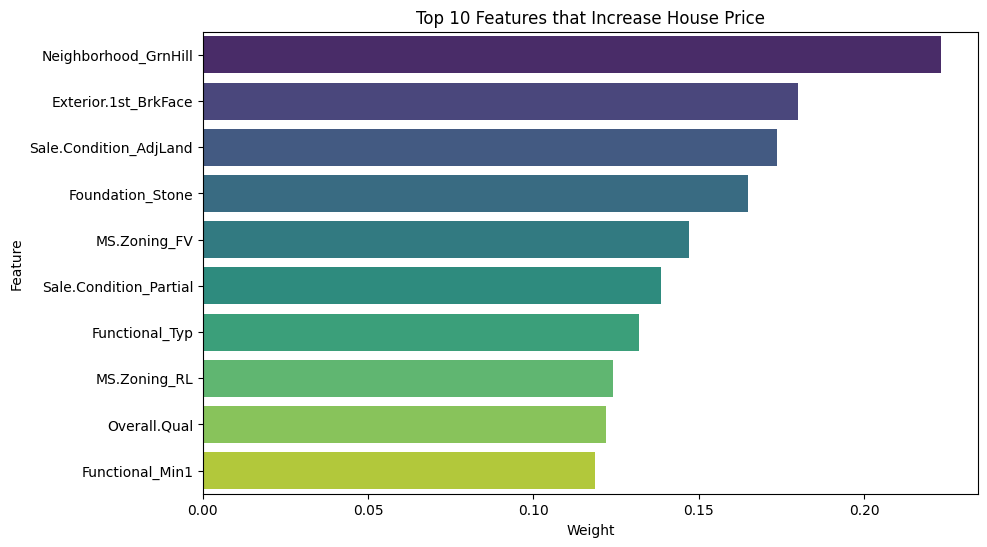

In [ ]:
# 1. Final Evaluation on Test Set
best_model = results["Ridge (L2)"]['model_obj'] # Assuming Ridge won
test_preds_log = best_model.predict(X_test_scaled)
test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test_log), np.expm1(test_preds_log)))
test_r2 = r2_score(y_test_log, test_preds_log)

print(f"🏆 FINAL TEST SCORE (The 'Unseen' Data) 🏆")
print(f"Test R2: {test_r2:.4f}")
print(f"Test RMSE: ${test_rmse:,.0f}")

# 2. Top 10 Price Drivers
coef_df = pd.DataFrame({'Feature': X.columns, 'Weight': best_model.coef_})
coef_df = coef_df.sort_values(by='Weight', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df.head(10), x='Weight', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title("Top 10 Features that Increase House Price")
plt.show()